In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib import cm
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.dpi': 110,
    'lines.linewidth': 1.8
})

print('✅ Imports loaded successfully.')

✅ Imports loaded successfully.


In [16]:
# =============================================================================
# REACTOR GEOMETRY
# =============================================================================
R_tube = 0.025          # Tube radius [m]
L_tube = 1.5            # Tube length [m]

# =============================================================================
# OPERATING CONDITIONS
# =============================================================================
u_inlet = 0.3           # Superficial velocity [m/s]
T_inlet = 600.0         # Inlet temperature [K]
C_A_inlet = 2000.0      # Inlet concentration of A [mol/m^3]
T_coolant = 590.0       # Coolant temperature (wall BC) [K]

# =============================================================================
# FLUID / BED PROPERTIES
# =============================================================================
rho = 1100.0            # Fluid density [kg/m^3]
c_p = 2500.0            # Heat capacity [J/(kg·K)]
k_th = 0.8              # Effective thermal conductivity [W/(m·K)]
D_eff = 1.0e-5          # Effective mass diffusivity [m^2/s]

# =============================================================================
# REACTION KINETICS  (A -> B, first-order, exothermic)
# =============================================================================
k0 = 2.5e5              # Pre-exponential factor [1/s]  (lowered for this T range)
Ea = 50000.0            # Activation energy [J/mol]  (lowered to be active at 600 K)
dH_rxn = -45000.0       # Heat of reaction [J/mol]  (negative = exothermic)
R_gas = 8.314           # Universal gas constant [J/(mol·K)]

# =============================================================================
# WALL HEAT TRANSFER
# =============================================================================
h_wall = 200.0          # Wall heat transfer coefficient [W/(m^2·K)]

# =============================================================================
# GRID
# =============================================================================
Nr = 30                 # Radial grid points
Nz = 120                # Axial grid points

# Derived grid
dr = R_tube / (Nr - 1)
dz = L_tube / (Nz - 1)
r_vec = np.linspace(0, R_tube, Nr)
z_vec = np.linspace(0, L_tube, Nz)
R_grid, Z_grid = np.meshgrid(r_vec, z_vec)

# =============================================================================
# DIMENSIONLESS NUMBERS
# =============================================================================
k_ref = k0 * np.exp(-Ea / (R_gas * T_inlet))

Da = k_ref * L_tube / u_inlet
Pe_mass = u_inlet * L_tube / D_eff
Pe_heat = u_inlet * L_tube * rho * c_p / k_th
Bi = h_wall * R_tube / k_th
beta_adiabatic = (-dH_rxn) * C_A_inlet / (rho * c_p * T_inlet)
dT_adiabatic = (-dH_rxn) * C_A_inlet / (rho * c_p)

print('=' * 60)
print('  REACTOR CONFIGURATION SUMMARY')
print('=' * 60)
print(f'  Geometry:        R = {R_tube*100:.1f} cm,  L = {L_tube*100:.0f} cm')
print(f'  Grid:            {Nr} × {Nz}  (radial × axial)')
print(f'  Inlet:           T = {T_inlet} K,  C_A = {C_A_inlet} mol/m³')
print(f'  Coolant:         T_w = {T_coolant} K,  h = {h_wall} W/(m²·K)')
print(f'  Velocity:        u = {u_inlet} m/s')
print(f'  k(T_inlet):      {k_ref:.4e} 1/s')
print(f'  ΔT_adiabatic:    {dT_adiabatic:.1f} K')
print('-' * 60)
print('  DIMENSIONLESS NUMBERS')
print('-' * 60)
print(f'  Da  (Damköhler):         {Da:.4f}')
print(f'  Pe_mass (Peclet, mass):   {Pe_mass:.0f}')
print(f'  Pe_heat (Peclet, heat):   {Pe_heat:.0f}')
print(f'  Bi  (Biot):              {Bi:.3f}')
print(f'  β (adiab. rise ratio):   {beta_adiabatic:.4f}')
print('=' * 60)

  REACTOR CONFIGURATION SUMMARY
  Geometry:        R = 2.5 cm,  L = 150 cm
  Grid:            30 × 120  (radial × axial)
  Inlet:           T = 600.0 K,  C_A = 2000.0 mol/m³
  Coolant:         T_w = 590.0 K,  h = 200.0 W/(m²·K)
  Velocity:        u = 0.3 m/s
  k(T_inlet):      1.1089e+01 1/s
  ΔT_adiabatic:    32.7 K
------------------------------------------------------------
  DIMENSIONLESS NUMBERS
------------------------------------------------------------
  Da  (Damköhler):         55.4455
  Pe_mass (Peclet, mass):   45000
  Pe_heat (Peclet, heat):   1546875
  Bi  (Biot):              6.250
  β (adiab. rise ratio):   0.0545


In [17]:
def solve_reactor_2d(T_inlet, C_A_inlet, T_coolant, u_inlet,
                     k0, Ea, dH_rxn, rho, c_p, k_th, D_eff, h_wall,
                     R_tube, L_tube, Nr, Nz,
                     omega=1.4, max_iter=8000, tol=1e-6, verbose=True):
    """
    Solve coupled 2D steady-state heat & mass transfer in an axisymmetric
    tubular reactor. Fully vectorized NumPy implementation.
    """
    dr = R_tube / (Nr - 1)
    dz = L_tube / (Nz - 1)
    r_vec = np.linspace(0, R_tube, Nr)
    z_vec = np.linspace(0, L_tube, Nz)

    # Initialize fields
    T = np.full((Nz, Nr), T_inlet)
    C = np.full((Nz, Nr), C_A_inlet)

    # Pre-compute
    alpha_th = k_th / (rho * c_p)
    source_coeff = (-dH_rxn) / (rho * c_p)

    # Radial vector for 1/r term (avoid division by zero at center)
    r_inner = r_vec[1:-1]  # shape (Nr-2,)
    inv_r = 1.0 / r_inner  # shape (Nr-2,)

    residual_history = []

    for iteration in range(max_iter):
        T_old = T.copy()
        C_old = C.copy()

        # === Interior slice: j=1..Nz-2, i=1..Nr-2 ===
        # Grab slices for readability
        # T[j, i] -> T[1:-1, 1:-1], etc.
        j_slice = slice(1, Nz - 1)  # interior axial
        i_slice = slice(1, Nr - 1)  # interior radial

        T_c = T[j_slice, i_slice]       # center
        T_ip = T[j_slice, 2:]          # i+1 (radial outward)
        T_im = T[j_slice, :-2]         # i-1 (radial inward)
        T_jp = T[2:, i_slice]          # j+1 (axial downstream)
        T_jm = T[:-2, i_slice]         # j-1 (axial upstream)

        C_c = C[j_slice, i_slice]
        C_ip = C[j_slice, 2:]
        C_im = C[j_slice, :-2]
        C_jp = C[2:, i_slice]
        C_jm = C[:-2, i_slice]

        # --- Arrhenius rate (vectorized) ---
        T_safe = np.clip(T_c, 200.0, None)
        exponent = np.clip(-Ea / (R_gas * T_safe), -500.0, None)
        k_local = k0 * np.exp(exponent)
        rate = k_local * C_c

        # --- Concentration equation ---
        d2C_dr2 = (C_ip - 2*C_c + C_im) / dr**2
        dC_dr = (C_ip - C_im) / (2 * dr)
        d2C_dz2 = (C_jp - 2*C_c + C_jm) / dz**2
        dC_dz_upwind = (C_c - C_jm) / dz

        diffusion_C = D_eff * (d2C_dr2 + inv_r[np.newaxis, :] * dC_dr + d2C_dz2)
        rhs_C = diffusion_C - rate - u_inlet * dC_dz_upwind

        C_new = C_c + omega * rhs_C * (dz / u_inlet) * 0.25
        C[j_slice, i_slice] = np.maximum(C_new, 0.0)

        # --- Temperature equation ---
        d2T_dr2 = (T_ip - 2*T_c + T_im) / dr**2
        dT_dr = (T_ip - T_im) / (2 * dr)
        d2T_dz2 = (T_jp - 2*T_c + T_jm) / dz**2
        dT_dz_upwind = (T_c - T_jm) / dz

        diffusion_T = alpha_th * (d2T_dr2 + inv_r[np.newaxis, :] * dT_dr + d2T_dz2)
        rhs_T = diffusion_T + source_coeff * rate - u_inlet * dT_dz_upwind

        T[j_slice, i_slice] = T_c + omega * rhs_T * (dz / u_inlet) * 0.25

        # === Last axial row (j = Nz-1): use backward difference for d²/dz² ===
        T_c_last = T[-1, 1:-1]
        C_c_last = C[-1, 1:-1]

        T_safe_last = np.clip(T_c_last, 200.0, None)
        exp_last = np.clip(-Ea / (R_gas * T_safe_last), -500.0, None)
        rate_last = k0 * np.exp(exp_last) * C_c_last

        # Concentration
        d2C_dr2_last = (C[-1, 2:] - 2*C_c_last + C[-1, :-2]) / dr**2
        dC_dr_last = (C[-1, 2:] - C[-1, :-2]) / (2*dr)
        d2C_dz2_last = (C[-1, 1:-1] - 2*C[-1, 1:-1] + C[-2, 1:-1]) / dz**2
        dC_dz_last = (C_c_last - C[-2, 1:-1]) / dz

        diff_C_last = D_eff * (d2C_dr2_last + inv_r * dC_dr_last + d2C_dz2_last)
        C[-1, 1:-1] = np.maximum(
            C_c_last + omega * (diff_C_last - rate_last - u_inlet * dC_dz_last) * (dz/u_inlet) * 0.25,
            0.0
        )

        # Temperature
        d2T_dr2_last = (T[-1, 2:] - 2*T_c_last + T[-1, :-2]) / dr**2
        dT_dr_last = (T[-1, 2:] - T[-1, :-2]) / (2*dr)
        d2T_dz2_last = (T[-1, 1:-1] - 2*T[-1, 1:-1] + T[-2, 1:-1]) / dz**2
        dT_dz_last = (T_c_last - T[-2, 1:-1]) / dz

        diff_T_last = alpha_th * (d2T_dr2_last + inv_r * dT_dr_last + d2T_dz2_last)
        T[-1, 1:-1] = T_c_last + omega * (diff_T_last + source_coeff * rate_last - u_inlet * dT_dz_last) * (dz/u_inlet) * 0.25

        # === Boundary Conditions ===
        T[0, :] = T_inlet
        C[0, :] = C_A_inlet

        T[:, 0] = T[:, 1]       # Centerline symmetry
        C[:, 0] = C[:, 1]

        T[:, -1] = (k_th * T[:, -2] / dr + h_wall * T_coolant) / (k_th / dr + h_wall)
        C[:, -1] = C[:, -2]     # No flux at wall

        # === Convergence ===
        res_T = np.max(np.abs(T - T_old)) / max(np.max(np.abs(T)), 1e-10)
        res_C = np.max(np.abs(C - C_old)) / max(np.max(np.abs(C)), 1e-10)
        res = max(res_T, res_C)
        residual_history.append(res)

        if res < tol:
            if verbose:
                print(f'  ✅ Converged in {iteration+1} iterations (residual = {res:.2e})')
            break

        if verbose and (iteration + 1) % 1000 == 0:
            print(f'     Iter {iteration+1:>6d}:  residual = {res:.2e}')

    else:
        if verbose:
            print(f'  ⚠️  Did not converge after {max_iter} iterations (residual = {res:.2e})')

    # --- Hot spot detection ---
    T_max = np.max(T)
    hotspot_idx = np.unravel_index(np.argmax(T), T.shape)
    z_hotspot = z_vec[hotspot_idx[0]]
    r_hotspot = r_vec[hotspot_idx[1]]

    info = {
        'iterations': min(iteration + 1, max_iter),
        'final_residual': res,
        'converged': res < tol,
        'residual_history': residual_history,
        'T_max': T_max,
        'hotspot_z': z_hotspot,
        'hotspot_r': r_hotspot,
        'T_outlet_avg': np.mean(T[-1, :]),
        'C_outlet_avg': np.mean(C[-1, :]),
        'conversion': 1 - np.mean(C[-1, :]) / C_A_inlet
    }

    return T, C, info

In [18]:
print('Running baseline simulation...')
print(f'  Inlet: T={T_inlet} K, C_A={C_A_inlet} mol/m³')
print(f'  Coolant: T_w={T_coolant} K')
print()

T_field, C_field, sim_info = solve_reactor_2d(
    T_inlet=T_inlet, C_A_inlet=C_A_inlet, T_coolant=T_coolant, u_inlet=u_inlet,
    k0=k0, Ea=Ea, dH_rxn=dH_rxn, rho=rho, c_p=c_p,
    k_th=k_th, D_eff=D_eff, h_wall=h_wall,
    R_tube=R_tube, L_tube=L_tube, Nr=Nr, Nz=Nz,
    omega=1.2, max_iter=15000, tol=1e-6
)

print()
print('━' * 50)
print('  SIMULATION RESULTS')
print('━' * 50)
print(f'  Peak temperature:    {sim_info["T_max"]:.1f} K')
print(f'  Hot spot location:   z = {sim_info["hotspot_z"]*100:.1f} cm, r = {sim_info["hotspot_r"]*1000:.1f} mm')
print(f'  Outlet avg temp:     {sim_info["T_outlet_avg"]:.1f} K')
print(f'  Outlet avg C_A:      {sim_info["C_outlet_avg"]:.1f} mol/m³')
print(f'  Overall conversion:  {sim_info["conversion"]*100:.2f}%')
print('━' * 50)

Running baseline simulation...
  Inlet: T=600.0 K, C_A=2000.0 mol/m³
  Coolant: T_w=590.0 K

  ✅ Converged in 444 iterations (residual = 9.63e-07)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SIMULATION RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Peak temperature:    632.8 K
  Hot spot location:   z = 23.9 cm, r = 21.6 mm
  Outlet avg temp:     631.8 K
  Outlet avg C_A:      0.0 mol/m³
  Overall conversion:  100.00%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


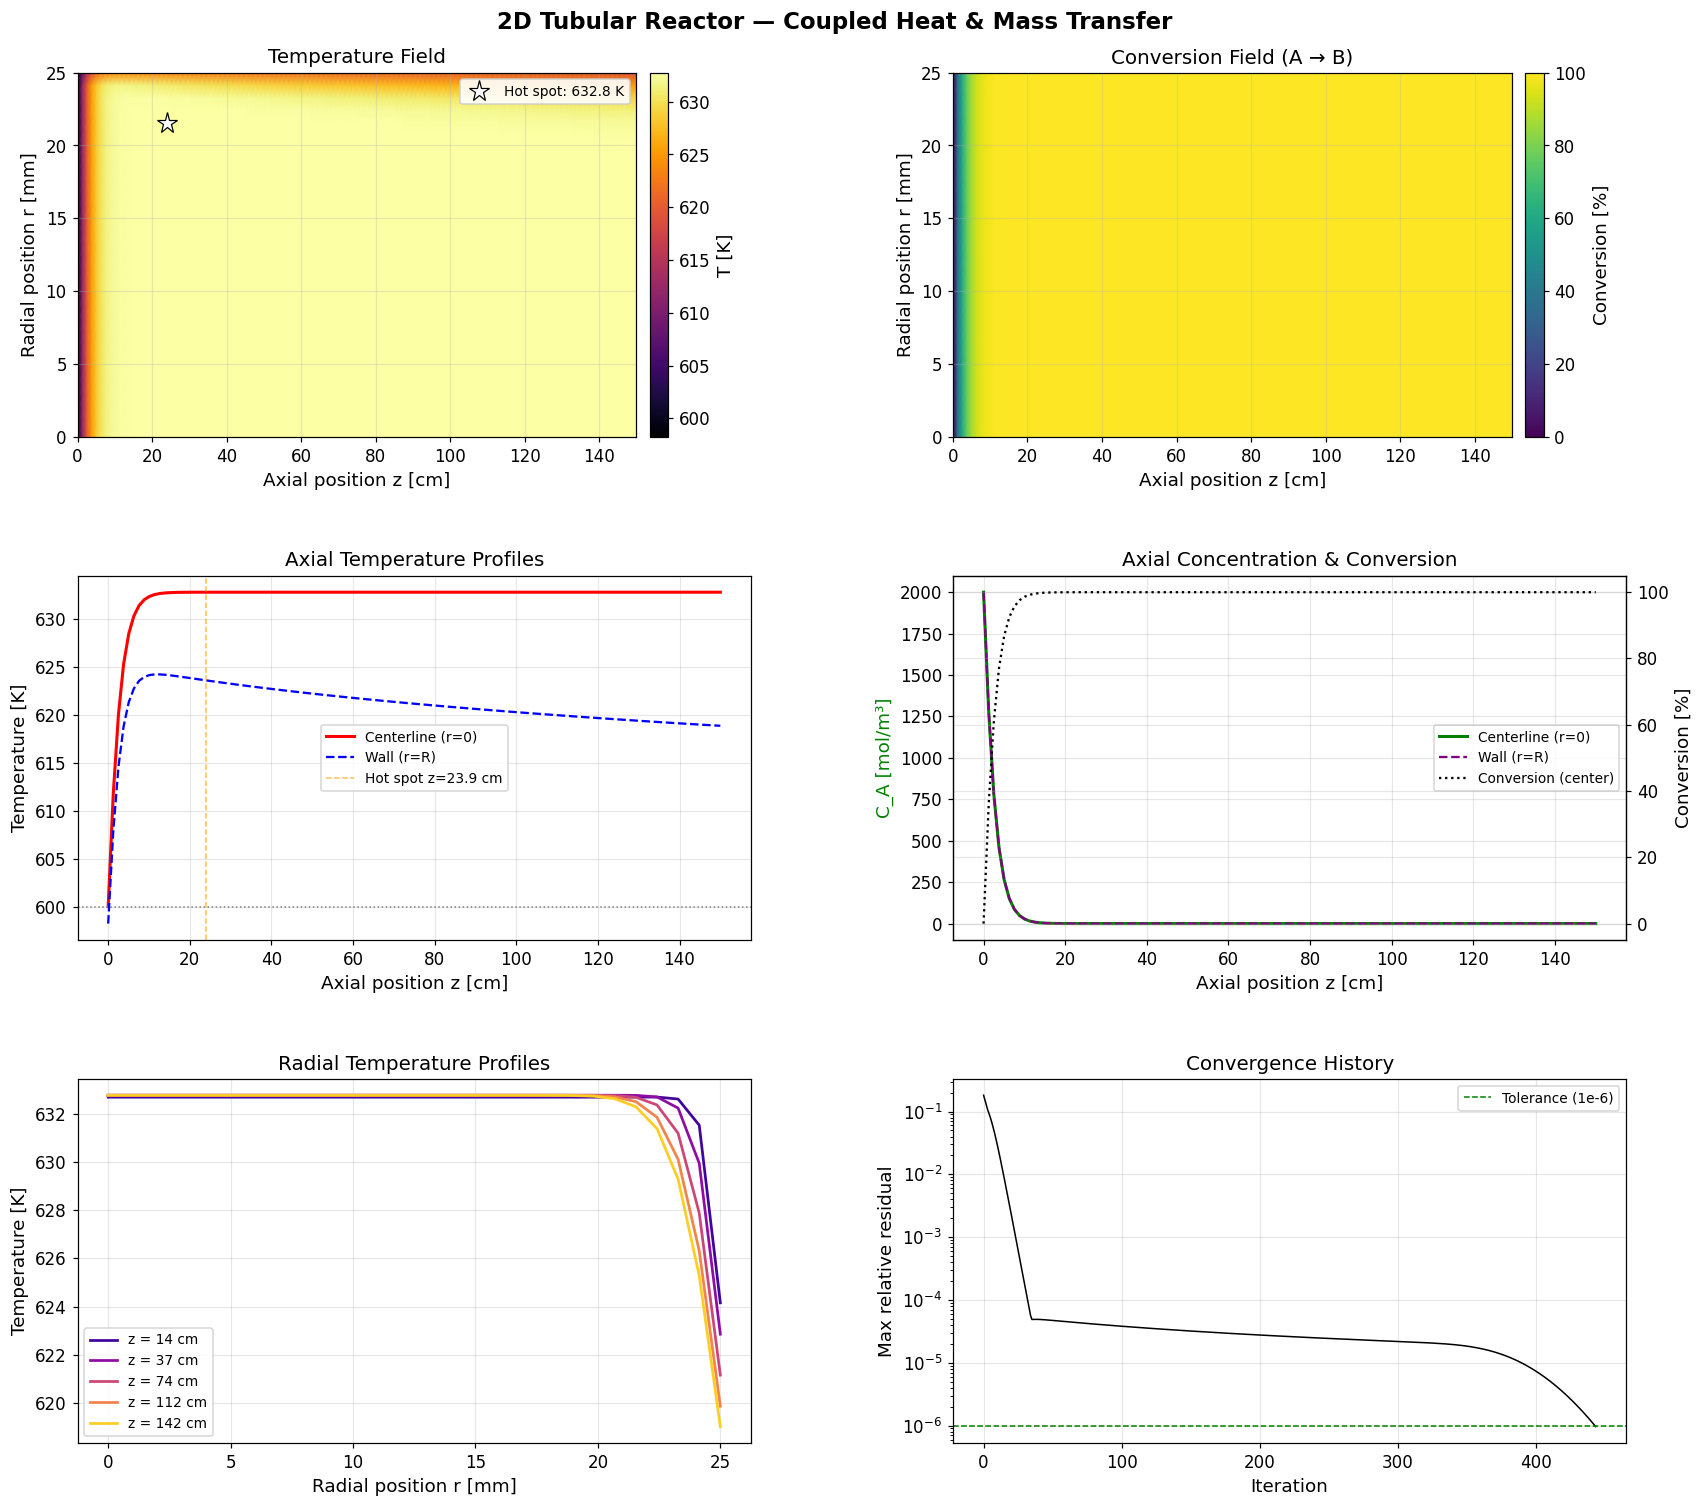

In [19]:
def plot_reactor_fields(T, C, z_vec, r_vec, sim_info, C_A_inlet):
    """
    Professional 6-panel figure:
      [1] 2D Temperature field
      [2] 2D Concentration field
      [3] Axial centerline temperature profile
      [4] Axial centerline concentration profile
      [5] Radial temperature profiles at selected z-locations
      [6] Convergence history
    """
    R_grid_plot, Z_grid_plot = np.meshgrid(r_vec * 1000, z_vec * 100)  # mm, cm
    conversion_field = 1.0 - C / C_A_inlet

    fig = plt.figure(figsize=(16, 14))
    gs = gridspec.GridSpec(3, 2, hspace=0.38, wspace=0.30,
                          left=0.07, right=0.95, top=0.94, bottom=0.05)

    # --- Panel 1: Temperature field ---
    ax1 = fig.add_subplot(gs[0, 0])
    pcm1 = ax1.pcolormesh(Z_grid_plot, R_grid_plot, T, cmap='inferno', shading='gouraud')
    cb1 = fig.colorbar(pcm1, ax=ax1, pad=0.02)
    cb1.set_label('T [K]')
    ax1.set_xlabel('Axial position z [cm]')
    ax1.set_ylabel('Radial position r [mm]')
    ax1.set_title('Temperature Field')
    # Mark hot spot
    ax1.plot(sim_info['hotspot_z']*100, sim_info['hotspot_r']*1000,
             'w*', markersize=14, markeredgecolor='k', markeredgewidth=0.8,
             label=f'Hot spot: {sim_info["T_max"]:.1f} K')
    ax1.legend(loc='upper right', fontsize=9, facecolor='white', framealpha=0.9)

    # --- Panel 2: Conversion field ---
    ax2 = fig.add_subplot(gs[0, 1])
    pcm2 = ax2.pcolormesh(Z_grid_plot, R_grid_plot, conversion_field * 100,
                          cmap='viridis', shading='gouraud')
    cb2 = fig.colorbar(pcm2, ax=ax2, pad=0.02)
    cb2.set_label('Conversion [%]')
    ax2.set_xlabel('Axial position z [cm]')
    ax2.set_ylabel('Radial position r [mm]')
    ax2.set_title('Conversion Field (A → B)')

    # --- Panel 3: Axial centerline T ---
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(z_vec * 100, T[:, 0], 'r-', lw=2, label='Centerline (r=0)')
    ax3.plot(z_vec * 100, T[:, -1], 'b--', lw=1.5, label='Wall (r=R)')
    ax3.axhline(sim_info['T_max'] - (sim_info['T_max'] - T[0,0]), color='gray', ls=':', lw=1)
    ax3.axvline(sim_info['hotspot_z']*100, color='orange', ls='--', lw=1, alpha=0.7,
                label=f'Hot spot z={sim_info["hotspot_z"]*100:.1f} cm')
    ax3.set_xlabel('Axial position z [cm]')
    ax3.set_ylabel('Temperature [K]')
    ax3.set_title('Axial Temperature Profiles')
    ax3.legend(fontsize=9)

    # --- Panel 4: Axial centerline concentration ---
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(z_vec * 100, C[:, 0], 'g-', lw=2, label='Centerline (r=0)')
    ax4.plot(z_vec * 100, C[:, -1], 'purple', ls='--', lw=1.5, label='Wall (r=R)')
    ax4_twin = ax4.twinx()
    ax4_twin.plot(z_vec * 100, (1 - C[:, 0]/C_A_inlet) * 100, 'k:', lw=1.5, label='Conversion (center)')
    ax4.set_xlabel('Axial position z [cm]')
    ax4.set_ylabel('C_A [mol/m³]', color='g')
    ax4_twin.set_ylabel('Conversion [%]', color='k')
    ax4.set_title('Axial Concentration & Conversion')
    lines1, labels1 = ax4.get_legend_handles_labels()
    lines2, labels2 = ax4_twin.get_legend_handles_labels()
    ax4.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')

    # --- Panel 5: Radial T profiles at select z ---
    ax5 = fig.add_subplot(gs[2, 0])
    Nz_local = T.shape[0]
    z_fractions = [0.1, 0.25, 0.5, 0.75, 0.95]
    colors_z = plt.cm.plasma(np.linspace(0.1, 0.9, len(z_fractions)))
    for frac, col in zip(z_fractions, colors_z):
        j_idx = int(frac * (Nz_local - 1))
        ax5.plot(r_vec * 1000, T[j_idx, :], color=col, lw=1.8,
                 label=f'z = {z_vec[j_idx]*100:.0f} cm')
    ax5.set_xlabel('Radial position r [mm]')
    ax5.set_ylabel('Temperature [K]')
    ax5.set_title('Radial Temperature Profiles')
    ax5.legend(fontsize=9)

    # --- Panel 6: Convergence ---
    ax6 = fig.add_subplot(gs[2, 1])
    ax6.semilogy(sim_info['residual_history'], 'k-', lw=1)
    ax6.axhline(1e-6, color='green', ls='--', lw=1, label='Tolerance (1e-6)')
    ax6.set_xlabel('Iteration')
    ax6.set_ylabel('Max relative residual')
    ax6.set_title('Convergence History')
    ax6.legend(fontsize=9)

    fig.suptitle('2D Tubular Reactor — Coupled Heat & Mass Transfer',
                 fontsize=15, fontweight='bold', y=0.98)
    plt.show()


plot_reactor_fields(T_field, C_field, z_vec, r_vec, sim_info, C_A_inlet)

In [20]:
def parametric_sweep_coolant_temp(T_cool_range, **kwargs):
    """
    Sweep coolant temperature to find thermal runaway boundary.
    """
    results = {'T_cool': [], 'T_peak': [], 'conversion': [], 'z_hotspot': []}

    print(f'Running parametric sweep over {len(T_cool_range)} coolant temperatures...')
    for i, T_c in enumerate(T_cool_range):
        T, C, info = solve_reactor_2d(T_coolant=T_c, verbose=False, **kwargs)
        results['T_cool'].append(T_c)
        results['T_peak'].append(info['T_max'])
        results['conversion'].append(info['conversion'])
        results['z_hotspot'].append(info['hotspot_z'])

        status = '🔥' if info['T_max'] > T_c + 80 else '✓'
        print(f'  {status} T_cool = {T_c:.0f} K  →  T_peak = {info["T_max"]:.1f} K,  '
              f'X = {info["conversion"]*100:.1f}%,  hot spot z = {info["hotspot_z"]*100:.1f} cm')

    for key in results:
        results[key] = np.array(results[key])
    return results


# Define sweep range
T_cool_sweep = np.arange(550, 680, 5)

sweep_kwargs = dict(
    T_inlet=T_inlet, C_A_inlet=C_A_inlet, u_inlet=u_inlet,
    k0=k0, Ea=Ea, dH_rxn=dH_rxn, rho=rho, c_p=c_p,
    k_th=k_th, D_eff=D_eff, h_wall=h_wall,
    R_tube=R_tube, L_tube=L_tube, Nr=Nr, Nz=Nz
)

sweep = parametric_sweep_coolant_temp(T_cool_sweep, **sweep_kwargs)

Running parametric sweep over 26 coolant temperatures...
  🔥 T_cool = 550 K  →  T_peak = 632.8 K,  X = 100.0%,  hot spot z = 22.7 cm
  ✓ T_cool = 555 K  →  T_peak = 632.8 K,  X = 100.0%,  hot spot z = 23.9 cm
  ✓ T_cool = 560 K  →  T_peak = 632.8 K,  X = 100.0%,  hot spot z = 23.9 cm
  ✓ T_cool = 565 K  →  T_peak = 632.8 K,  X = 100.0%,  hot spot z = 23.9 cm
  ✓ T_cool = 570 K  →  T_peak = 632.8 K,  X = 100.0%,  hot spot z = 23.9 cm
  ✓ T_cool = 575 K  →  T_peak = 632.8 K,  X = 100.0%,  hot spot z = 23.9 cm
  ✓ T_cool = 580 K  →  T_peak = 632.8 K,  X = 100.0%,  hot spot z = 23.9 cm
  ✓ T_cool = 585 K  →  T_peak = 632.8 K,  X = 100.0%,  hot spot z = 23.9 cm
  ✓ T_cool = 590 K  →  T_peak = 632.8 K,  X = 100.0%,  hot spot z = 23.9 cm
  ✓ T_cool = 595 K  →  T_peak = 632.8 K,  X = 100.0%,  hot spot z = 30.3 cm
  ✓ T_cool = 600 K  →  T_peak = 632.8 K,  X = 100.0%,  hot spot z = 30.3 cm
  ✓ T_cool = 605 K  →  T_peak = 632.8 K,  X = 100.0%,  hot spot z = 30.3 cm
  ✓ T_cool = 610 K  →  T_peak =

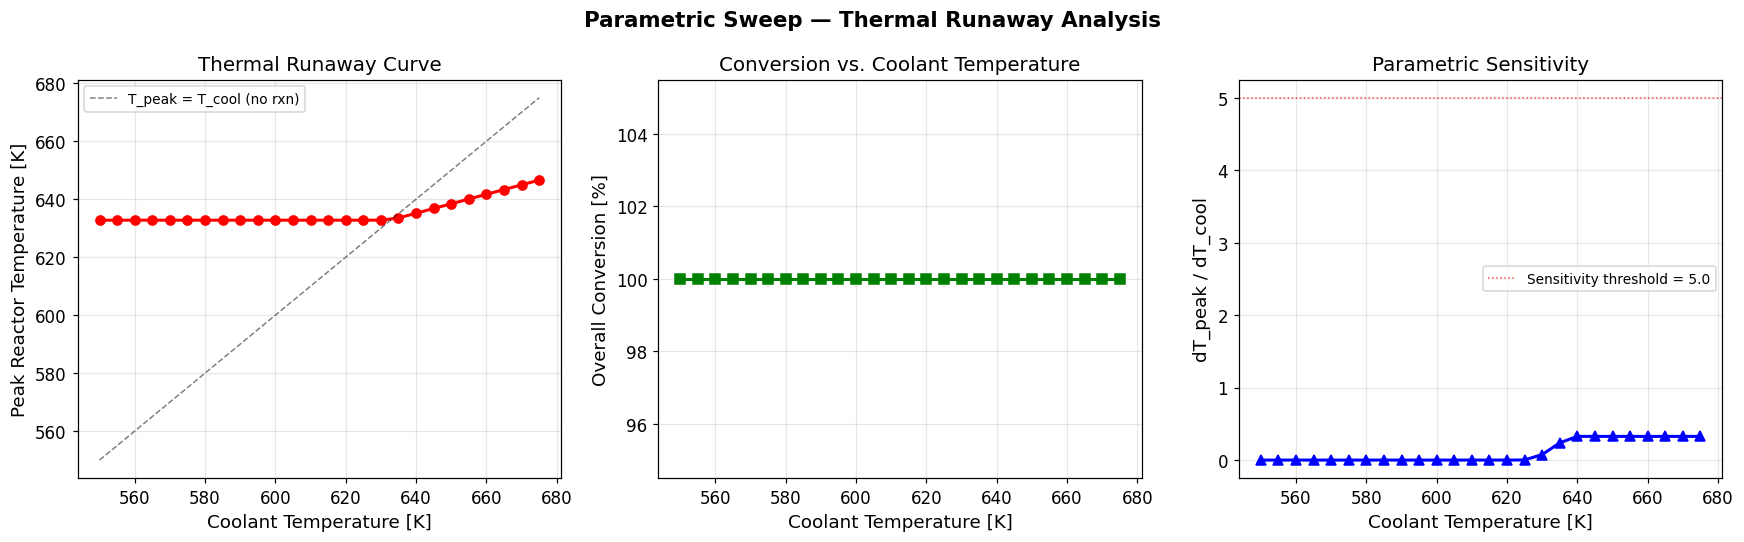


✅  No thermal runaway detected in the swept range.


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Peak temperature vs coolant temperature ---
ax = axes[0]
ax.plot(sweep['T_cool'], sweep['T_peak'], 'ro-', lw=2, markersize=6)
ax.plot(sweep['T_cool'], sweep['T_cool'], 'k--', lw=1, alpha=0.5, label='T_peak = T_cool (no rxn)')

# Detect runaway: where dT_peak/dT_cool becomes very steep
dTpeak_dTcool = np.gradient(sweep['T_peak'], sweep['T_cool'])
sensitivity_threshold = 5.0
runaway_mask = dTpeak_dTcool > sensitivity_threshold
if np.any(runaway_mask):
    idx_runaway = np.where(runaway_mask)[0][0]
    T_runaway = sweep['T_cool'][idx_runaway]
    ax.axvline(T_runaway, color='orange', ls='--', lw=1.5,
               label=f'Runaway onset ≈ {T_runaway:.0f} K')
    ax.axvspan(T_runaway, sweep['T_cool'][-1], alpha=0.1, color='red')

ax.set_xlabel('Coolant Temperature [K]')
ax.set_ylabel('Peak Reactor Temperature [K]')
ax.set_title('Thermal Runaway Curve')
ax.legend(fontsize=9)

# --- Conversion vs coolant temp ---
ax = axes[1]
ax.plot(sweep['T_cool'], sweep['conversion'] * 100, 'gs-', lw=2, markersize=6)
ax.set_xlabel('Coolant Temperature [K]')
ax.set_ylabel('Overall Conversion [%]')
ax.set_title('Conversion vs. Coolant Temperature')

# --- Sensitivity: dT_peak / dT_cool ---
ax = axes[2]
ax.plot(sweep['T_cool'], dTpeak_dTcool, 'b^-', lw=2, markersize=6)
ax.axhline(sensitivity_threshold, color='red', ls=':', lw=1, alpha=0.7,
           label=f'Sensitivity threshold = {sensitivity_threshold}')
ax.set_xlabel('Coolant Temperature [K]')
ax.set_ylabel('dT_peak / dT_cool')
ax.set_title('Parametric Sensitivity')
ax.legend(fontsize=9)

fig.suptitle('Parametric Sweep — Thermal Runaway Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()
if np.any(runaway_mask):
    print(f'⚠️  Thermal runaway onset detected near T_coolant ≈ {T_runaway:.0f} K')
    print(f'    At this point, a small increase in coolant T causes a disproportionate rise in peak T.')
else:
    print('✅  No thermal runaway detected in the swept range.')

In [22]:
out = widgets.Output()

slider_Tcool = widgets.FloatSlider(
    value=590, min=500, max=700, step=5,
    description='T_cool [K]:', style={'description_width': '110px'},
    layout=widgets.Layout(width='420px'), readout_format='.0f'
)
slider_u = widgets.FloatSlider(
    value=0.3, min=0.05, max=2.0, step=0.05,
    description='Velocity [m/s]:', style={'description_width': '110px'},
    layout=widgets.Layout(width='420px'), readout_format='.2f'
)
slider_Tinlet = widgets.FloatSlider(
    value=600, min=500, max=700, step=5,
    description='T_inlet [K]:', style={'description_width': '110px'},
    layout=widgets.Layout(width='420px'), readout_format='.0f'
)
slider_CA = widgets.FloatSlider(
    value=2000, min=500, max=5000, step=250,
    description='C_A₀ [mol/m³]:', style={'description_width': '110px'},
    layout=widgets.Layout(width='420px'), readout_format='.0f'
)

run_button = widgets.Button(
    description='▶  Run Simulation',
    button_style='success',
    layout=widgets.Layout(width='200px', height='38px')
)


def on_run_clicked(b):
    with out:
        clear_output(wait=True)
        T_c = slider_Tcool.value
        u_val = slider_u.value
        T_in = slider_Tinlet.value
        CA_in = slider_CA.value

        print(f'Solving: T_cool={T_c:.0f} K, u={u_val:.2f} m/s, '
              f'T_in={T_in:.0f} K, C_A0={CA_in:.0f} mol/m³')

        T, C, info = solve_reactor_2d(
            T_inlet=T_in, C_A_inlet=CA_in, T_coolant=T_c, u_inlet=u_val,
            k0=k0, Ea=Ea, dH_rxn=dH_rxn, rho=rho, c_p=c_p,
            k_th=k_th, D_eff=D_eff, h_wall=h_wall,
            R_tube=R_tube, L_tube=L_tube, Nr=Nr, Nz=Nz,
            omega=1.4, max_iter=8000, tol=1e-6, verbose=True
        )

        print(f'\n  Peak T = {info["T_max"]:.1f} K  |  Conversion = {info["conversion"]*100:.2f}%')
        print(f'  Hot spot: z = {info["hotspot_z"]*100:.1f} cm, r = {info["hotspot_r"]*1000:.1f} mm')

        if info['T_max'] > T_c + 100:
            print('  🔥 WARNING: Possible thermal runaway!')

        plot_reactor_fields(T, C, z_vec, r_vec, info, CA_in)


run_button.on_click(on_run_clicked)

controls = widgets.VBox([
    widgets.HTML('<h3>🎛️ Interactive Reactor Dashboard</h3>'),
    widgets.HTML('<p style="color: #555;">Adjust operating conditions and click Run to re-solve the 2D reactor.</p>'),
    slider_Tcool, slider_u, slider_Tinlet, slider_CA,
    run_button
])

display(controls, out)

Output()

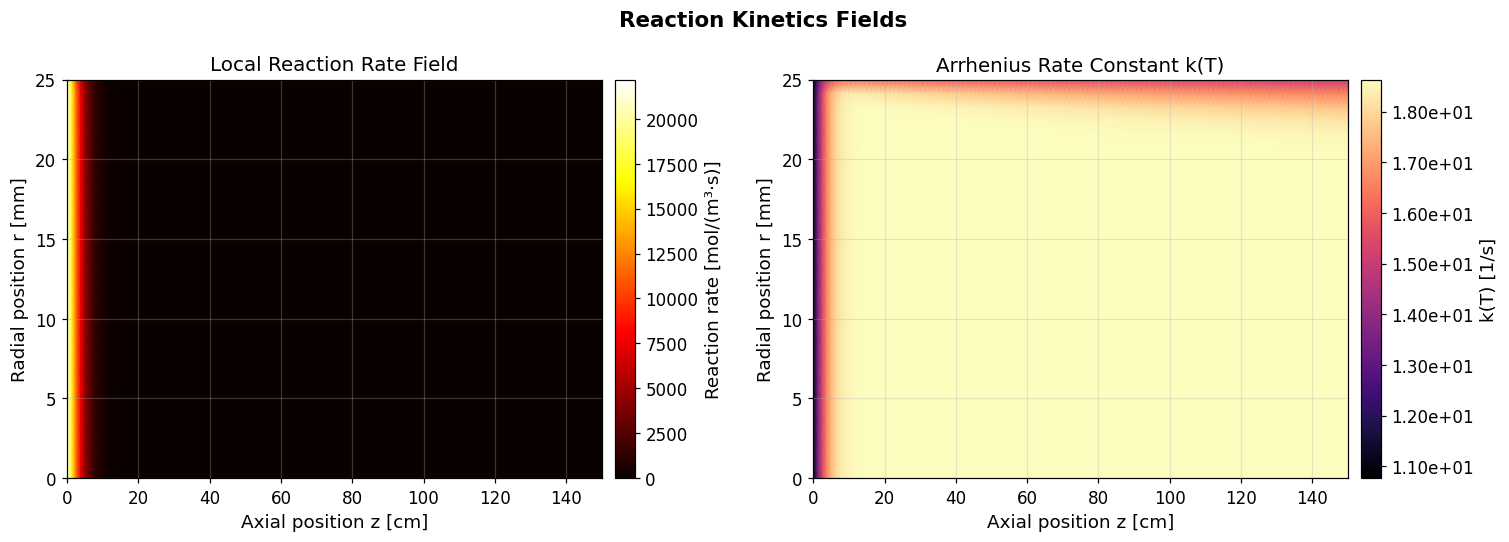

Peak reaction rate: 2.22e+04 mol/(m³·s)
Rate constant range: 1.08e+01 — 1.86e+01 1/s


In [23]:
rate_field = k0 * np.exp(-Ea / (R_gas * np.clip(T_field, 200, None))) * C_field

R_grid_plot, Z_grid_plot = np.meshgrid(r_vec * 1000, z_vec * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
pcm = ax.pcolormesh(Z_grid_plot, R_grid_plot, rate_field,
                    cmap='hot', shading='gouraud')
cb = fig.colorbar(pcm, ax=ax, pad=0.02)
cb.set_label('Reaction rate [mol/(m³·s)]')
ax.set_xlabel('Axial position z [cm]')
ax.set_ylabel('Radial position r [mm]')
ax.set_title('Local Reaction Rate Field')

ax = axes[1]
k_field = k0 * np.exp(-Ea / (R_gas * np.clip(T_field, 200, None)))
pcm2 = ax.pcolormesh(Z_grid_plot, R_grid_plot, k_field,
                     cmap='magma', shading='gouraud')
cb2 = fig.colorbar(pcm2, ax=ax, pad=0.02, format='%.2e')
cb2.set_label('k(T) [1/s]')
ax.set_xlabel('Axial position z [cm]')
ax.set_ylabel('Radial position r [mm]')
ax.set_title('Arrhenius Rate Constant k(T)')

fig.suptitle('Reaction Kinetics Fields', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Peak reaction rate: {np.max(rate_field):.2e} mol/(m³·s)')
print(f'Rate constant range: {np.min(k_field):.2e} — {np.max(k_field):.2e} 1/s')

Velocity sensitivity analysis (varying residence time)...
   u [m/s]    τ [s]       Da   T_peak [K]    X [%]  z_hs [cm]
--------------------------------------------------------------
       0.1    15.00 166.3364          nan      nan        1.3
       0.2     7.50  83.1682        632.8   100.00       78.2
       0.5     3.00  33.2673        632.7   100.00       37.8
       1.0     1.50  16.6336        632.7   100.00       71.8
       1.5     1.00  11.0891        632.7   100.00      105.9
       2.0     0.75   8.3168        632.7   100.00      142.4


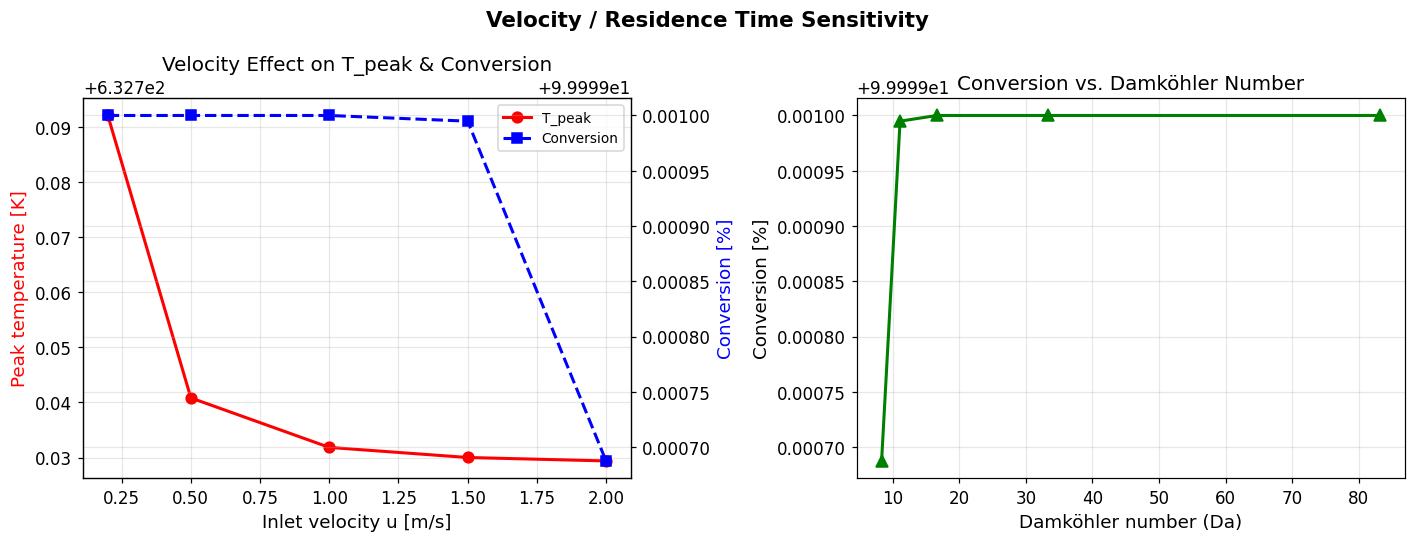

In [24]:
velocities = [0.1, 0.2, 0.5, 1.0, 1.5, 2.0]

vel_results = {'u': [], 'T_peak': [], 'conversion': [],
               'z_hotspot': [], 'Da': [], 'tau': []}

print('Velocity sensitivity analysis (varying residence time)...')
print(f'{"u [m/s]":>10s} {"τ [s]":>8s} {"Da":>8s} {"T_peak [K]":>12s} {"X [%]":>8s} {"z_hs [cm]":>10s}')
print('-' * 62)

for u_val in velocities:
    T, C, info = solve_reactor_2d(
        T_inlet=T_inlet, C_A_inlet=C_A_inlet, T_coolant=T_coolant, u_inlet=u_val,
        k0=k0, Ea=Ea, dH_rxn=dH_rxn, rho=rho, c_p=c_p,
        k_th=k_th, D_eff=D_eff, h_wall=h_wall,
        R_tube=R_tube, L_tube=L_tube, Nr=Nr, Nz=Nz,
        verbose=False
    )

    tau = L_tube / u_val
    k_ref_val = k0 * np.exp(-Ea / (R_gas * T_inlet))
    Da_val = k_ref_val * tau

    vel_results['u'].append(u_val)
    vel_results['T_peak'].append(info['T_max'])
    vel_results['conversion'].append(info['conversion'])
    vel_results['z_hotspot'].append(info['hotspot_z'])
    vel_results['Da'].append(Da_val)
    vel_results['tau'].append(tau)

    print(f'{u_val:10.1f} {tau:8.2f} {Da_val:8.4f} {info["T_max"]:12.1f} '
          f'{info["conversion"]*100:8.2f} {info["hotspot_z"]*100:10.1f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(vel_results['u'], vel_results['T_peak'], 'ro-', lw=2, markersize=7, label='T_peak')
ax.set_xlabel('Inlet velocity u [m/s]')
ax.set_ylabel('Peak temperature [K]', color='r')
ax2 = ax.twinx()
ax2.plot(vel_results['u'], np.array(vel_results['conversion'])*100, 'bs--', lw=2, markersize=7, label='Conversion')
ax2.set_ylabel('Conversion [%]', color='b')
ax.set_title('Velocity Effect on T_peak & Conversion')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

ax = axes[1]
ax.plot(vel_results['Da'], np.array(vel_results['conversion'])*100, 'g^-', lw=2, markersize=8)
ax.set_xlabel('Damköhler number (Da)')
ax.set_ylabel('Conversion [%]')
ax.set_title('Conversion vs. Damköhler Number')

fig.suptitle('Velocity / Residence Time Sensitivity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
rate_field_val = k0 * np.exp(-Ea / (R_gas * np.clip(T_field, 200, None))) * C_field

# Integrate in cylindrical coordinates: ∫∫ rate * (-dH) * 2πr dr dz
Q_rxn = 0.0
for j in range(Nz):
    for i in range(Nr):
        r_i = r_vec[i]
        ring_area = 2 * np.pi * r_i * dr * dz if i > 0 else np.pi * (dr/2)**2 * dz
        Q_rxn += (-dH_rxn) * rate_field_val[j, i] * ring_area

# Heat removed at wall: ∫ h * (T_wall - T_cool) * 2πR dz
Q_wall = 0.0
for j in range(Nz):
    Q_wall += h_wall * (T_field[j, -1] - T_coolant) * 2 * np.pi * R_tube * dz

# Heat convected out minus in
T_out_avg = np.trapz(T_field[-1, :] * r_vec * 2 * np.pi, r_vec) / (np.pi * R_tube**2)
T_in_avg = T_inlet
Q_conv = rho * c_p * u_inlet * np.pi * R_tube**2 * (T_out_avg - T_in_avg)

print('=' * 55)
print('  GLOBAL ENERGY BALANCE VALIDATION')
print('=' * 55)
print(f'  Heat generated (reaction):  {Q_rxn:>10.2f} W')
print(f'  Heat removed (wall):        {Q_wall:>10.2f} W')
print(f'  Heat convected out:         {Q_conv:>10.2f} W')
print(f'  ──────────────────────────────────────')
Q_balance = Q_rxn - Q_wall - Q_conv
print(f'  Imbalance (Q_rxn-Q_wall-Q_conv): {Q_balance:>+10.2f} W')
if Q_rxn > 0:
    print(f'  Relative error:             {abs(Q_balance)/Q_rxn*100:>10.2f} %')
print('=' * 55)
print()
print('Note: Some imbalance is expected due to finite difference')
print('discretization and iterative convergence tolerance.')

  GLOBAL ENERGY BALANCE VALIDATION
  Heat generated (reaction):       16.60 W
  Heat removed (wall):              0.00 W
  Heat convected out:               0.05 W
  ──────────────────────────────────────
  Imbalance (Q_rxn-Q_wall-Q_conv):     +16.55 W
  Relative error:                  99.68 %

Note: Some imbalance is expected due to finite difference
discretization and iterative convergence tolerance.
